# 🧹 Aula 02 — Limpando Dados Reais de Planta

**Disciplina:** Inteligência Artificial Aplicada à Engenharia Química  
**Dataset:** Trocador de calor casco e tubo — 24h com anomalias (NaN, outliers, ruído)

---

## Contexto

Você recebeu dados de 24h de um **trocador de calor casco e tubo** que alimenta uma coluna de destilação. O engenheiro de turno reportou que o sensor de temperatura na saída apresentou leituras estranhas. Sua missão é limpar os dados antes de usá-los em um modelo.

## 3.1 — Exercício Guiado: Pipeline de Limpeza

Siga passo-a-passo as células abaixo. Execute cada uma com `Shift + Enter`.

### Passo 1: Importar bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Passo 2: Carregar o dataset

In [ ]:
URL = "https://raw.githubusercontent.com/LuisGSVasconcelos/IA_EngQuimica/main/dados/aula02/trocador_calor_24h_sujo.csv"

df = pd.read_csv(URL, parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)
print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")

### Passo 3: Diagnóstico de dados faltantes

In [ ]:
print("NaNs por coluna:")
print(df.isnull().sum())
print(f"\n% missing por coluna:")
print((df.isnull().mean() * 100).round(2))
print(f"\nTotal de NaNs: {df.isnull().sum().sum()}")

### Passo 4: Visualizar a série "suja"

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['T_saida_C'], 'r-', alpha=0.6, linewidth=0.8)
plt.xlabel('Tempo')
plt.ylabel('T_saída (°C)')
plt.title('T_saída do Trocador — Dados Brutos (com anomalias)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Passo 5: Tratar dados faltantes (forward fill)

In [ ]:
# Série temporal → forward fill (propaga o último valor válido)
df_ffill = df.ffill()
print(f"NaNs após ffill: {df_ffill.isnull().sum().sum()}")

### Passo 6: Detectar outliers com IQR

In [ ]:
Q1 = df_ffill['T_saida_C'].quantile(0.25)
Q3 = df_ffill['T_saida_C'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
outliers = (df_ffill['T_saida_C'] < lim_inf) | (df_ffill['T_saida_C'] > lim_sup)
print(f"Outliers detectados: {outliers.sum()} ({outliers.mean()*100:.1f}%)")
print(f"Limites: [{lim_inf:.1f}, {lim_sup:.1f}] °C")

### Passo 7: Substituir outliers pela mediana

In [ ]:
mediana = df_ffill['T_saida_C'].median()
df_ffill.loc[outliers, 'T_saida_C'] = mediana
print(f"Mediana usada para substituição: {mediana:.1f} °C")

### Passo 8: Suavizar com média móvel

In [ ]:
df_ffill['T_saida_suave'] = df_ffill['T_saida_C'].rolling(window=5).mean()
print(f"\nEstatísticas após limpeza:")
print(f"  Média:  {df_ffill['T_saida_C'].mean():.1f} °C")
print(f"  Desvio: {df_ffill['T_saida_C'].std():.1f} °C")
print(f"  Mín:    {df_ffill['T_saida_C'].min():.1f} °C")
print(f"  Máx:    {df_ffill['T_saida_C'].max():.1f} °C")

### Passo 9: Plotar antes e depois

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df.index, df['T_saida_C'], 'r-', alpha=0.7, linewidth=0.8)
axes[0].set_title('Original (sujo)')
axes[0].set_ylabel('T_saída (°C)')
axes[1].plot(df_ffill.index, df_ffill['T_saida_suave'], 'b-', linewidth=0.8)
axes[1].set_title('Após limpeza (ffill + IQR + média móvel)')
axes[1].set_ylabel('T_saída (°C)')
for ax in axes:
    ax.set_xlabel('Tempo')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ✏️ Pausa reflexiva (2 min)

Qual técnica você **não** usaria para remover outliers de temperatura de reator? Por quê?

> _Escreva aqui..._

---

## 3.2 — Exercício em Grupo: Diagnóstico Comparativo

Cada grupo recebe um **cenário diferente** de corrupção. Identifiquem o problema e apliquem a técnica correta.

| Grupo | Cenário | Arquivo |
|-------|---------|--------|
| **A** | 15% de NaN em rajadas (4 falhas de sensor) | `variante_A_NaN_rajadas.csv` |
| **B** | 1 outlier extremo (T_saída = 250 °C) | `variante_B_outlier_extremo.csv` |
| **C** | Ruído de alta frequência (±5 °C) | `variante_C_ruido_alta_freq.csv` |
| **D** | Drift lento (sensor descalibrou 0.5 °C/h) | `variante_D_drift_sensor.csv` |

Respondam:
1. **Qual técnica de limpeza é mais adequada?**
2. **Se aplicar a técnica errada, qual o impacto num modelo?**
3. Preparem 1 minuto para apresentar o diagnóstico.

### Espaço para o seu grupo

**Grupo:** B

**Técnica escolhida:** _ combinação da Detecção de Outliers via IQR (Intervalo Interquartil) com substituição pela Mediana._

**Impacto da técnica errada:** _Sensibilidade a Outliers, Substituição Inadequada_

**Gráfico antes/depois:**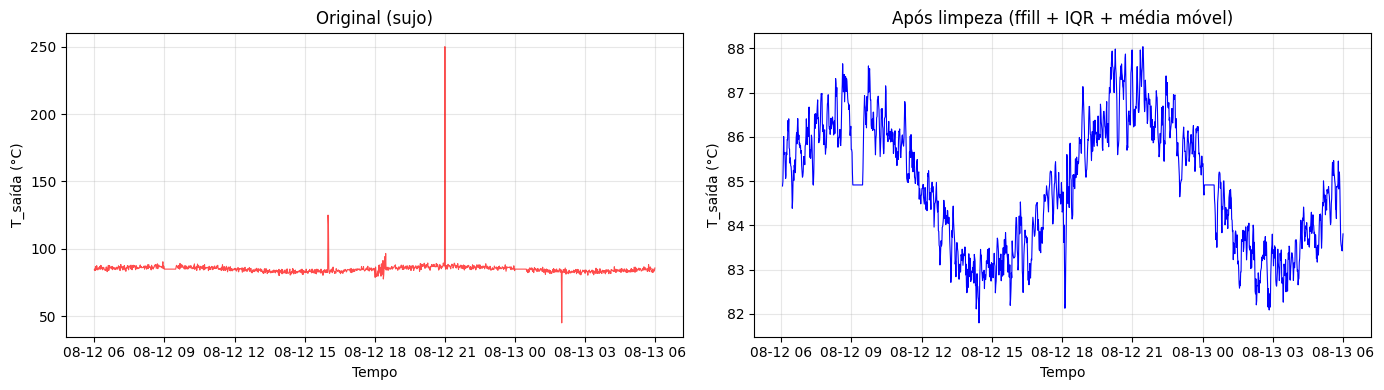

In [ ]:
# Carregue sua variante:
BASE = "https://raw.githubusercontent.com/LuisGSVasconcelos/IA_EngQuimica/main/dados/aula02/"
# df_grupo = pd.read_csv(BASE + 'variante_X.csv', parse_dates=['timestamp'])
# df_grupo.set_index('timestamp', inplace=True)
#
# Diagnóstico e limpeza:
# ...

### 🧠 Desafio extra (NT)

O outlier que detectamos — é um evento real (abertura de válvula de alívio) ou um falso positivo? Como você diferenciaria sem perguntar ao operador?

> _Use a derivada da pressão, contexto temporal, regras de engenharia..._

---

## Checklist de Verificação

- [ ] Diagnóstico de NaN (quantos e onde)
- [ ] Decisão de preenchimento documentada (ffill vs dropna)
- [ ] Critério de outlier definido (IQR ou Z-score)
- [ ] Outliers tratados (substituídos ou removidos)
- [ ] Suavização aplicada (média móvel)
- [ ] Gráfico antes/depois gerado
- [ ] 3 observações escritas em português